In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans # Here is where you import the k-means algorithm from scikit-learn.
import pylab as pl # PyLab is a convenience module that bulk imports matplotlib.
from sklearn.preprocessing import StandardScaler # Penting untuk standarisasi

In [3]:
# This option ensures that the graphs you create are displayed within the notebook without the need to "call" them specifically.

%matplotlib inline

In [4]:
# Define path

path = r'C:\Users\johan\Documents\Indonesia Integrated Seismic Risk Analysis'

In [5]:
path

'C:\\Users\\johan\\Documents\\Indonesia Integrated Seismic Risk Analysis'

In [6]:
print(path)

C:\Users\johan\Documents\Indonesia Integrated Seismic Risk Analysis


In [7]:
# Load data 
path = r'C:\Users\johan\Documents\Indonesia Integrated Seismic Risk Analysis'
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared data', 'katalog_gempa_cleaned.csv'))

In [8]:
df.shape

(92887, 12)

In [9]:
df.head()

,Date,Time,Latitude,Longitude,Depth,Magnitude,Location,Full_DateTime,Time_in_seconds,Year,Month,Magnitude_Category
0,2008-11-01,02:43.1,-9.18,119.06,10,4.9,Sumba Region - Indonesia,2008-11-01 00:02:43.100,163.1,2008,11,Moderate (4-6)
1,2008-11-01,58:50.2,-6.55,129.64,10,4.6,Banda Sea,2008-11-01 00:58:50.200,3530.2,2008,11,Moderate (4-6)
2,2008-11-01,43:12.9,-7.01,106.63,121,3.7,Java - Indonesia,2008-11-01 00:43:12.900,2592.9,2008,11,Minor (2-4)
3,2008-11-01,24:14.8,-3.30,127.85,10,3.2,Seram - Indonesia,2008-11-01 00:24:14.800,1454.8,2008,11,Minor (2-4)
4,2008-11-01,20:37.3,-6.41,129.54,70,4.3,Banda Sea,2008-11-01 00:20:37.300,1237.3,2008,11,Moderate (4-6)


In [10]:
df_numeric = df[['Latitude', 'Longitude', 'Depth', 'Magnitude']]

In [11]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

#### @. The Elbow technique

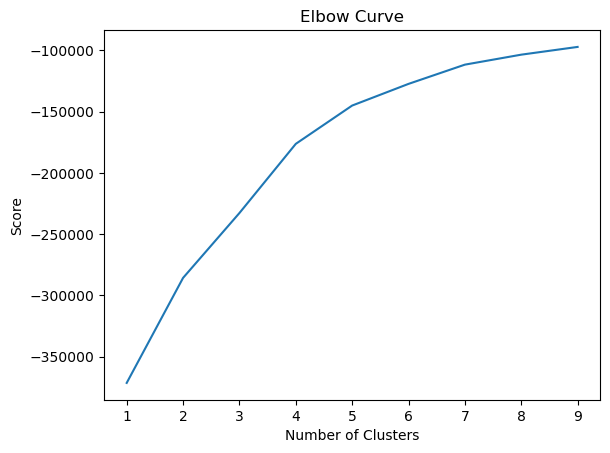

In [12]:
num_cl = range(1, 10) 
kmeans = [KMeans(n_clusters=i) for i in num_cl]
score = [kmeans[i].fit(df_scaled).score(df_scaled) for i in range(len(kmeans))]

# Plot the elbow curve
plt.plot(num_cl, score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

In [13]:
# Ganti n_clusters sesuai hasil elbow (misal 3)
kmeans = KMeans(n_clusters=3, n_init=10)
kmeans.fit(df_scaled)

# Masukkan hasil cluster kembali ke dataframe asli
df['clusters'] = kmeans.fit_predict(df_scaled)

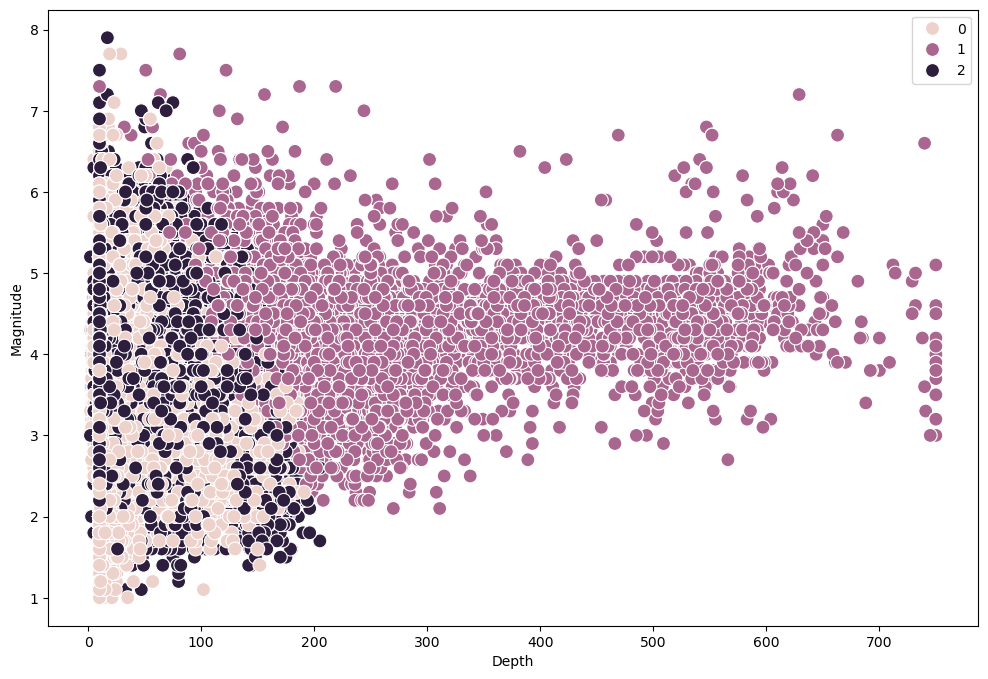

In [14]:
plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df['Depth'], y=df['Magnitude'], hue=kmeans.labels_, s=100)
ax.grid(False) 
plt.xlabel('Depth')
plt.ylabel('Magnitude')
plt.show()

In [15]:
df.head()

,Date,Time,Latitude,Longitude,Depth,Magnitude,Location,Full_DateTime,Time_in_seconds,Year,Month,Magnitude_Category,clusters
0,2008-11-01,02:43.1,-9.18,119.06,10,4.9,Sumba Region - Indonesia,2008-11-01 00:02:43.100,163.1,2008,11,Moderate (4-6),0
1,2008-11-01,58:50.2,-6.55,129.64,10,4.6,Banda Sea,2008-11-01 00:58:50.200,3530.2,2008,11,Moderate (4-6),2
2,2008-11-01,43:12.9,-7.01,106.63,121,3.7,Java - Indonesia,2008-11-01 00:43:12.900,2592.9,2008,11,Minor (2-4),0
3,2008-11-01,24:14.8,-3.30,127.85,10,3.2,Seram - Indonesia,2008-11-01 00:24:14.800,1454.8,2008,11,Minor (2-4),2
4,2008-11-01,20:37.3,-6.41,129.54,70,4.3,Banda Sea,2008-11-01 00:20:37.300,1237.3,2008,11,Moderate (4-6),2


In [16]:
df.columns

Index(['Date', 'Time', 'Latitude', 'Longitude', 'Depth', 'Magnitude',
       'Location', 'Full_DateTime', 'Time_in_seconds', 'Year', 'Month',
       'Magnitude_Category', 'clusters'],
      dtype='object')

In [17]:
# Simpan data yang sudah ada kolom clusternya
df.to_csv(os.path.join(path, '02 Data', 'Prepared data', 'katalog_gempa_with_clusters.csv'), index=False)